In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Processed Dataset

In [2]:
file_path = "../data/processed/imdb_movies_ratings.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 156380
Columns: 14


In [6]:
df.head()

,Title_ID,Content_Type,Title,Original_Title,Is_Adult,Release_Year,End_Year,Runtime_Minutes,Genres,IMDb_Rating,IMDb_Votes,Rating_Category,Decade,Popularity_Category
0,tt0035423,movie,Kate & Leopold,Kate & Leopold,0,2001.0,NaN,118.0,"Comedy,Fantasy,Romance",6.4,94417,Average,2000.0,High
1,tt0036606,movie,"Another Time, Another Place","Another Time, Another Place",0,1983.0,NaN,118.0,"Drama,War",6.4,386,Average,1980.0,Low
2,tt0059325,movie,Born in '45,Jahrgang 45,0,1990.0,NaN,94.0,"Drama,Romance",6.5,297,Average,1990.0,Low
3,tt0062181,movie,Hands Up!,Rece do góry,0,1981.0,NaN,80.0,Drama,6.5,513,Average,1980.0,Low
4,tt0062336,movie,The Tango of the Widower and Its Distorting Mi...,El tango del viudo y su espejo deformante,0,2020.0,NaN,70.0,"Drama,Mystery",6.3,297,Average,2020.0,Low


In [7]:
df.tail()

,Title_ID,Content_Type,Title,Original_Title,Is_Adult,Release_Year,End_Year,Runtime_Minutes,Genres,IMDb_Rating,IMDb_Votes,Rating_Category,Decade,Popularity_Category
156375,tt9916128,tvSeries,Salt City,Salt City (India),0,2022.0,NaN,NaN,Drama,6.1,3744,Average,2020.0,Medium
156376,tt9916190,movie,Safeguard,Safeguard,0,2020.0,NaN,95.0,"Action,Adventure,Thriller",3.6,270,Low Rated,2020.0,Low
156377,tt9916270,movie,Il talento del calabrone,Il talento del calabrone,0,2020.0,NaN,84.0,Thriller,5.9,1558,Low Rated,2020.0,Medium
156378,tt9916362,movie,Coven,Akelarre,0,2020.0,NaN,92.0,"Drama,History,Horror",6.4,6335,Average,2020.0,Medium
156379,tt9916380,tvSeries,Meie aasta Aafrikas,Meie aasta Aafrikas,0,2019.0,NaN,43.0,"Adventure,Comedy,Family",8.2,127,Excellent,2010.0,Low


In [13]:
df.columns.tolist()

['Title_ID',
 'Content_Type',
 'Title',
 'Original_Title',
 'Is_Adult',
 'Release_Year',
 'End_Year',
 'Runtime_Minutes',
 'Genres',
 'IMDb_Rating',
 'IMDb_Votes',
 'Rating_Category',
 'Decade',
 'Popularity_Category']

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156380 entries, 0 to 156379
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Title_ID             156380 non-null  object 
 1   Content_Type         156380 non-null  object 
 2   Title                156380 non-null  object 
 3   Original_Title       156380 non-null  object 
 4   Is_Adult             156380 non-null  int64  
 5   Release_Year         156380 non-null  float64
 6   End_Year             28193 non-null   float64
 7   Runtime_Minutes      141177 non-null  float64
 8   Genres               155867 non-null  object 
 9   IMDb_Rating          156380 non-null  float64
 10  IMDb_Votes           156380 non-null  int64  
 11  Rating_Category      156380 non-null  object 
 12  Decade               156380 non-null  float64
 13  Popularity_Category  156380 non-null  object 
dtypes: float64(5), int64(2), object(7)
memory usage: 16.7+ MB


In [17]:
df.describe()

,Is_Adult,Release_Year,End_Year,Runtime_Minutes,IMDb_Rating,IMDb_Votes,Decade
count,156380.0,156380.000000,28193.000000,1.411770e+05,156380.000000,1.563800e+05,156380.000000
mean,0.0,2010.924639,2013.377044,1.192554e+02,6.098287,8.820016e+03,2006.550582
std,0.0,11.595203,10.635880,9.827835e+03,1.389795,5.781838e+04,11.971493
min,0.0,1980.000000,1980.000000,1.000000e+00,1.000000,1.000000e+02,1980.000000
25%,0.0,2004.000000,2007.000000,8.000000e+01,5.300000,1.950000e+02,2000.000000
50%,0.0,2014.000000,2017.000000,9.300000e+01,6.300000,4.620000e+02,2010.000000
75%,0.0,2020.000000,2022.000000,1.070000e+02,7.100000,1.737000e+03,2020.000000
max,0.0,2026.000000,2027.000000,3.692080e+06,9.900000,3.221305e+06,2020.000000


In [18]:
df["IMDb_Rating"].describe()

count    156380.000000
mean          6.098287
std           1.389795
min           1.000000
25%           5.300000
50%           6.300000
75%           7.100000
max           9.900000
Name: IMDb_Rating, dtype: float64

In [20]:
df["IMDb_Votes"].describe()

count    1.563800e+05
mean     8.820016e+03
std      5.781838e+04
min      1.000000e+02
25%      1.950000e+02
50%      4.620000e+02
75%      1.737000e+03
max      3.221305e+06
Name: IMDb_Votes, dtype: float64

In [21]:
df["Runtime_Minutes"].describe()

count    1.411770e+05
mean     1.192554e+02
std      9.827835e+03
min      1.000000e+00
25%      8.000000e+01
50%      9.300000e+01
75%      1.070000e+02
max      3.692080e+06
Name: Runtime_Minutes, dtype: float64

In [22]:
# Check for missing values in the dataset

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

missing

End_Year           128187
Runtime_Minutes     15203
Genres                513
dtype: int64

In [23]:
# Calculate the percentage of missing values for each column

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

End_Year           81.971480
Runtime_Minutes     9.721831
Genres              0.328047
dtype: float64

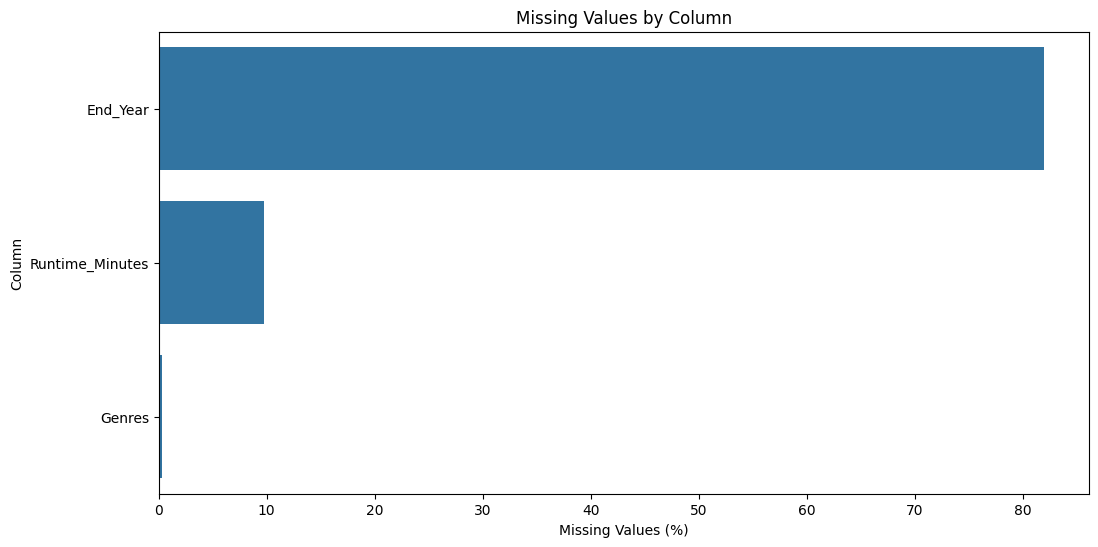

In [24]:
# Visualize the missing values using a bar plot

plt.figure(figsize=(12, 6))

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.show()

What type of content dominates our dataset?

In [25]:
content_counts = df["Content_Type"].value_counts()

content_counts

Content_Type
movie           115741
tvSeries         32716
tvMiniSeries      7923
Name: count, dtype: int64

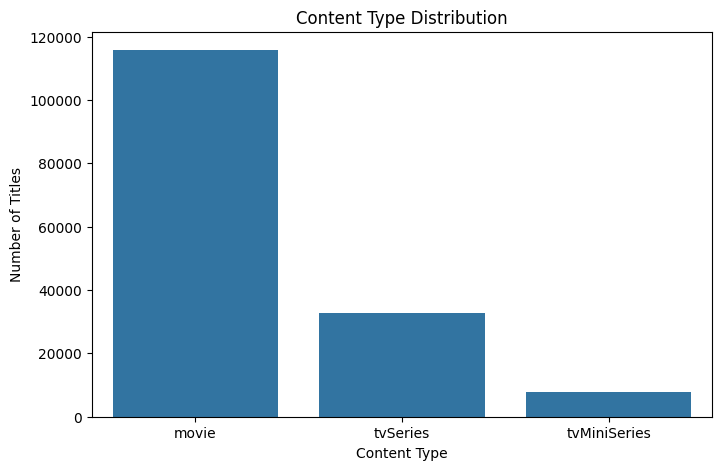

In [26]:
# Visualize the distribution of content types using a bar plot

plt.figure(figsize=(8, 5))

sns.barplot(
    x=content_counts.index,
    y=content_counts.values
)

plt.title("Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [27]:
# Calculate the percentage of each content type

content_percentage = (
    df["Content_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

content_percentage

Content_Type
movie           74.01
tvSeries        20.92
tvMiniSeries     5.07
Name: proportion, dtype: float64

Titles Released Per Year

In [28]:
# Calculate the number of titles released each year

yearly_content = (
    df.groupby("Release_Year")
      .size()
      .reset_index(name="Title_Count")
)

yearly_content.head()

,Release_Year,Title_Count
0,1980.0,981
1,1981.0,1032
2,1982.0,1063
3,1983.0,1118
4,1984.0,1125


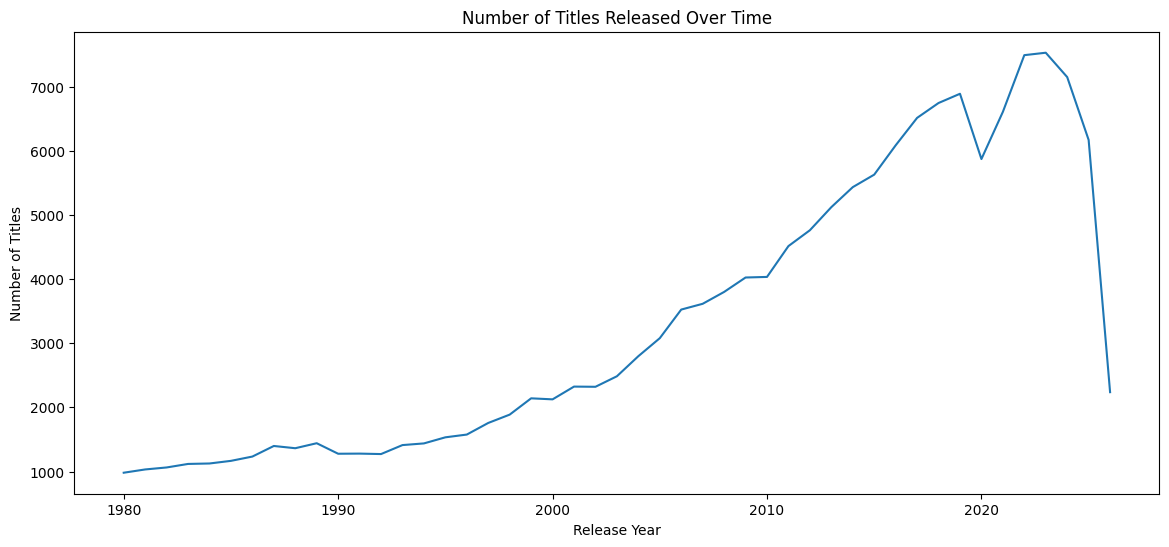

In [29]:
# Visualize the number of titles released over time using a line plot

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=yearly_content,
    x="Release_Year",
    y="Title_Count"
)

plt.title("Number of Titles Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

Separate Movie and TV Trends

In [30]:
# Calculate the number of titles released each year by content type

yearly_type = (
    df.groupby(
        ["Release_Year", "Content_Type"]
    )
    .size()
    .reset_index(name="Title_Count")
)

yearly_type.head()

,Release_Year,Content_Type,Title_Count
0,1980.0,movie,833
1,1980.0,tvMiniSeries,41
2,1980.0,tvSeries,107
3,1981.0,movie,894
4,1981.0,tvMiniSeries,26


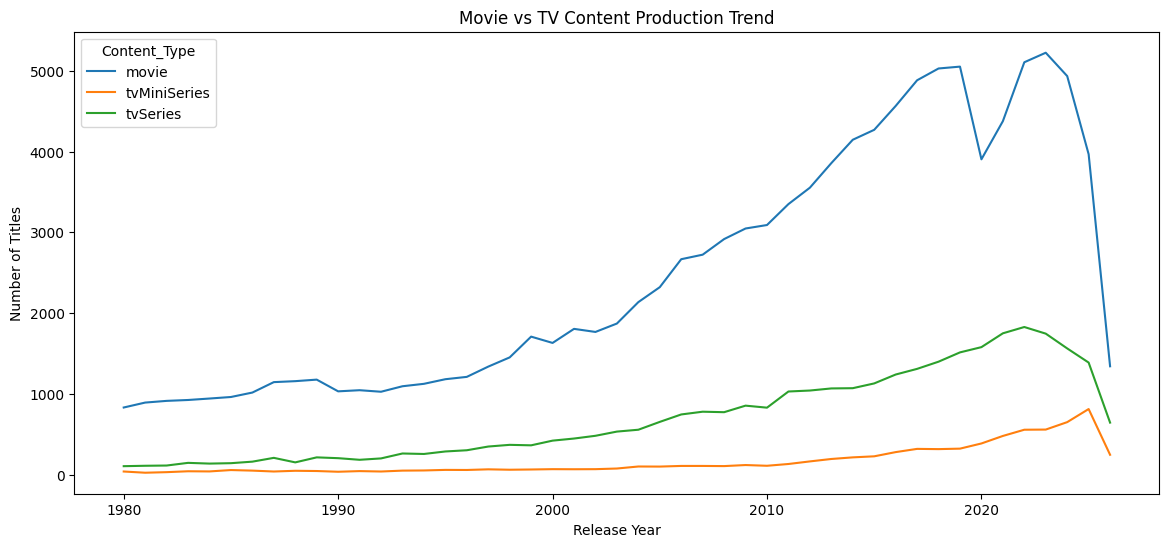

In [31]:
# Visualize the number of titles released over time by content type using a line plot

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=yearly_type,
    x="Release_Year",
    y="Title_Count",
    hue="Content_Type"
)

plt.title("Movie vs TV Content Production Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

Rating Distribution

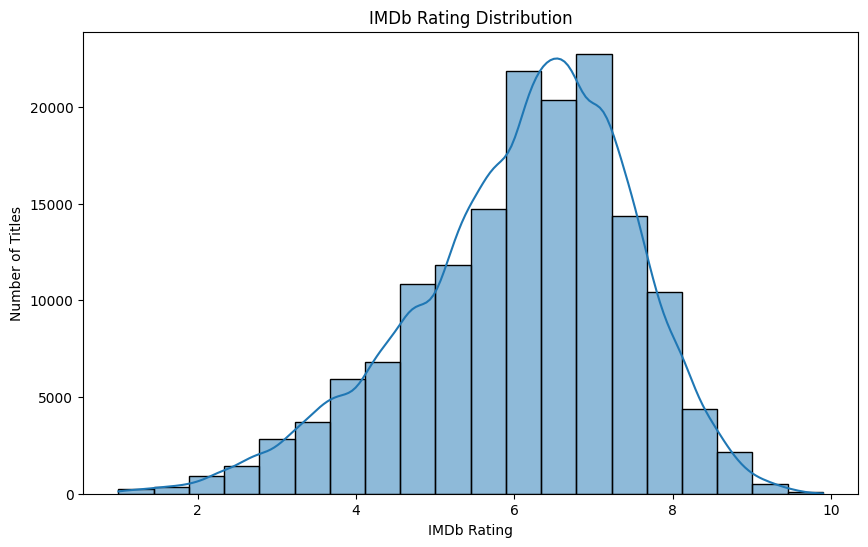

In [32]:
# Visualize the distribution of IMDb ratings using a histogram

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="IMDb_Rating",
    bins=20,
    kde=True
)

plt.title("IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Titles")

plt.show()

Average Rating

In [33]:
average_rating = df["IMDb_Rating"].mean()

print(
    f"Average IMDb Rating: {average_rating:.2f}"
)

Average IMDb Rating: 6.10


Rating Category Distribution

In [34]:
rating_categories = (
    df["Rating_Category"]
    .value_counts()
)

rating_categories

Rating_Category
Low Rated      63337
Average        47590
Good           34824
Excellent       9803
Masterpiece      826
Name: count, dtype: int64

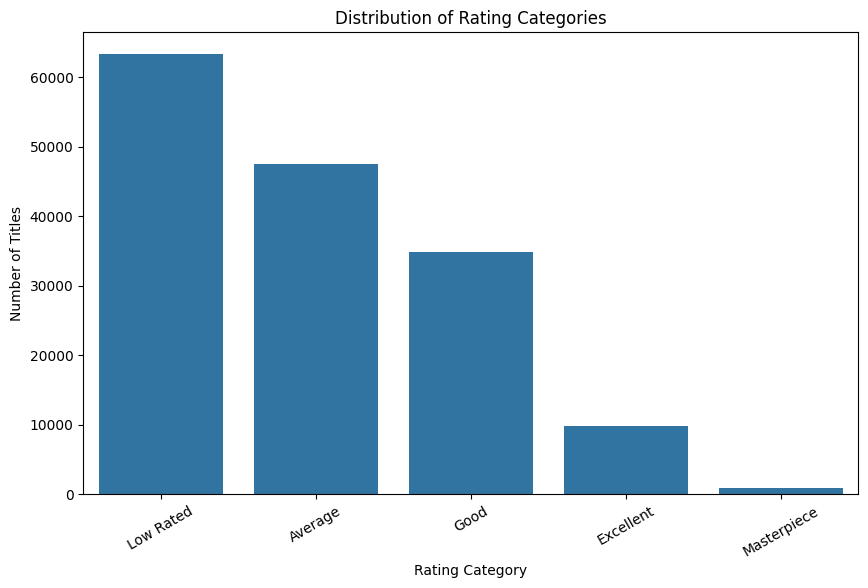

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_categories.index,
    y=rating_categories.values
)

plt.title("Distribution of Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Titles")

plt.xticks(rotation=30)

plt.show()

Top 20 Rated Titles

In [36]:
# Find the top 20 movies and TV shows based on IMDb rating and number of votes

top_20 = (
    df.sort_values(
        by=["IMDb_Rating", "IMDb_Votes"],
        ascending=[False, False]
    )
    .head(20)
)

top_20[
    [
        "Title",
        "Content_Type",
        "Release_Year",
        "Genres",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
]

,Title,Content_Type,Release_Year,Genres,IMDb_Rating,IMDb_Votes
124493,Lyonheart Universe,tvMiniSeries,2025.0,"Action,Sci-Fi,Thriller",9.9,903
127564,Yaar Jigree Kasooti Degree,movie,2026.0,Drama,9.9,623
128374,Raithara Makkalige Hennu Kodi,movie,2026.0,Family,9.9,105
126568,Trap Father,tvSeries,2026.0,Drama,9.8,547
117398,Borderline Forever,movie,2021.0,"Adventure,Comedy,Fantasy",9.8,142
120053,Out the Game,movie,2025.0,Thriller,9.8,136
97297,OdBita Pot,tvSeries,2022.0,Adventure,9.7,1348
124241,Boss,movie,2026.0,"Crime,Thriller",9.7,558
119183,From China with Love,movie,2025.0,"Crime,Drama,Thriller",9.7,549
126610,Get Set Go,movie,2026.0,"Action,Thriller",9.7,243


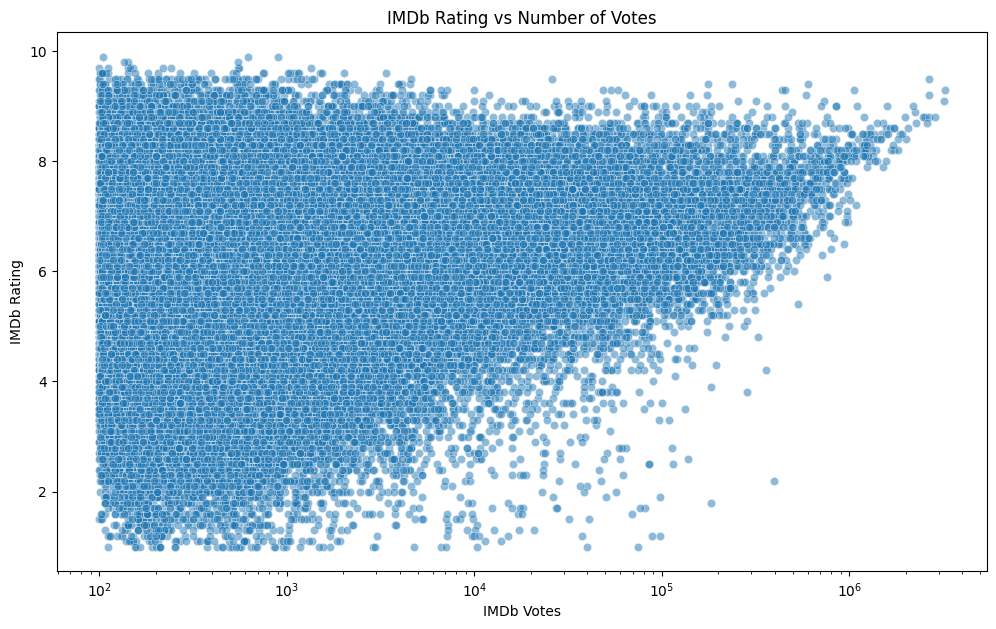

In [37]:
# Visualize the relationship between IMDb rating and number of votes using a scatter plot

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="IMDb_Votes",
    y="IMDb_Rating",
    alpha=0.5
)

plt.title("IMDb Rating vs Number of Votes")
plt.xlabel("IMDb Votes")
plt.ylabel("IMDb Rating")

plt.xscale("log")

plt.show()

In [38]:
# Calculate the correlation between IMDb rating and number of votes

correlation = df[
    ["IMDb_Rating", "IMDb_Votes"]
].corr()

correlation

,IMDb_Rating,IMDb_Votes
IMDb_Rating,1.000000,0.109587
IMDb_Votes,0.109587,1.000000


In [39]:
rating_vote_corr = df[
    ["IMDb_Rating", "IMDb_Votes"]
].corr().loc[
    "IMDb_Rating",
    "IMDb_Votes"
]

print(
    f"Rating-Votes Correlation: {rating_vote_corr:.3f}"
)

Rating-Votes Correlation: 0.110


Decade Analysis

In [40]:
decade_analysis = (
    df.groupby("Decade")
      .agg(
          Titles=("Title", "count"),
          Average_Rating=("IMDb_Rating", "mean"),
          Average_Votes=("IMDb_Votes", "mean")
      )
      .reset_index()
)

decade_analysis

,Decade,Titles,Average_Rating,Average_Votes
0,1980.0,11920,6.185789,7138.974413
1,1990.0,15572,6.145479,11960.304778
2,2000.0,30097,6.059597,12438.291225
3,2010.0,55732,6.052254,9176.631038
4,2020.0,43059,6.143622,5159.069602


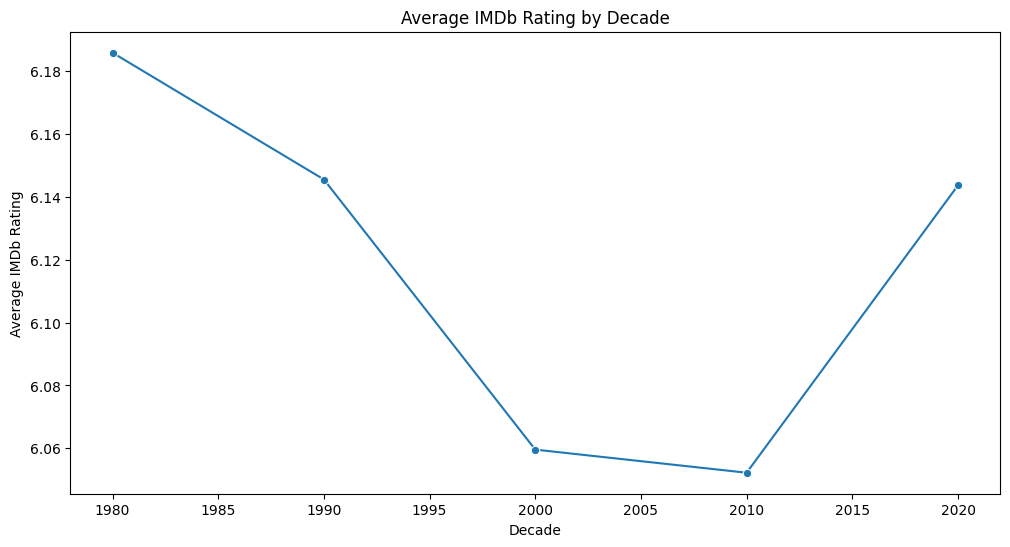

In [41]:
# Visualize the average IMDb rating by decade using a line plot

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=decade_analysis,
    x="Decade",
    y="Average_Rating",
    marker="o"
)

plt.title("Average IMDb Rating by Decade")
plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")

plt.show()

Genre Analysis

In [42]:
genre_df = df[
    ["Title", "Genres", "IMDb_Rating", "IMDb_Votes"]
].dropna(
    subset=["Genres"]
).copy()

genre_df["Genres"] = genre_df["Genres"].str.split(",")

In [43]:
genre_df = genre_df.explode("Genres")

genre_df.head()

,Title,Genres,IMDb_Rating,IMDb_Votes
0,Kate & Leopold,Comedy,6.4,94417
0,Kate & Leopold,Fantasy,6.4,94417
0,Kate & Leopold,Romance,6.4,94417
1,"Another Time, Another Place",Drama,6.4,386
1,"Another Time, Another Place",War,6.4,386


In [44]:
genre_analysis = (
    genre_df.groupby("Genres")
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Average_Votes=("IMDb_Votes", "mean")
    )
    .reset_index()
)

In [45]:
genre_analysis.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,Genres,Titles,Average_Rating,Average_Votes
6,Documentary,17081,7.110017,1372.251976
20,Short,437,7.059497,1119.933638
11,History,5696,6.907935,7258.753160
3,Biography,5850,6.878581,14410.591282
13,Music,4034,6.684308,6545.351760
21,Sport,2822,6.640858,8012.097094
2,Animation,9372,6.627571,10794.493278
24,War,2242,6.508653,10096.126673
10,Game-Show,1140,6.326754,1249.340351
17,Reality-TV,3253,6.266400,968.928989


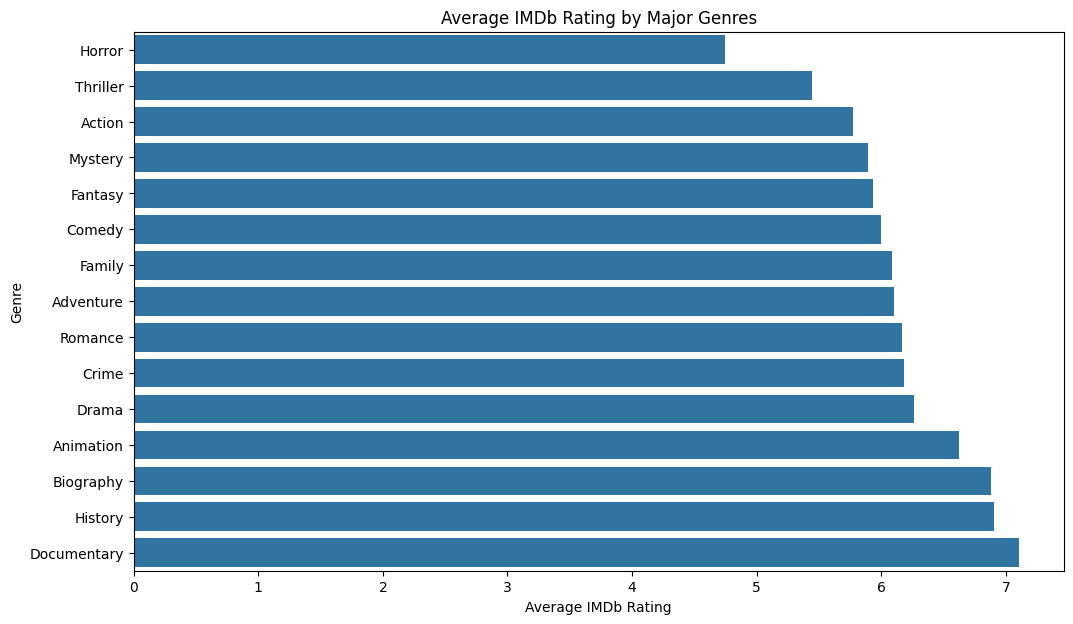

In [46]:
# Visualize the average IMDb rating by major genres using a bar plot

top_genres = (
    genre_analysis
    .sort_values(
        "Titles",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_genres.sort_values("Average_Rating"),
    x="Average_Rating",
    y="Genres"
)

plt.title("Average IMDb Rating by Major Genres")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")

plt.show()

Movie vs TV Rating

In [47]:
type_rating = (
    df.groupby("Content_Type")
      .agg(
          Titles=("Title", "count"),
          Average_Rating=("IMDb_Rating", "mean"),
          Median_Rating=("IMDb_Rating", "median")
      )
      .reset_index()
)

type_rating

,Content_Type,Titles,Average_Rating,Median_Rating
0,movie,115741,5.827577,6.0
1,tvMiniSeries,7923,7.153061,7.2
2,tvSeries,32716,6.800550,7.0


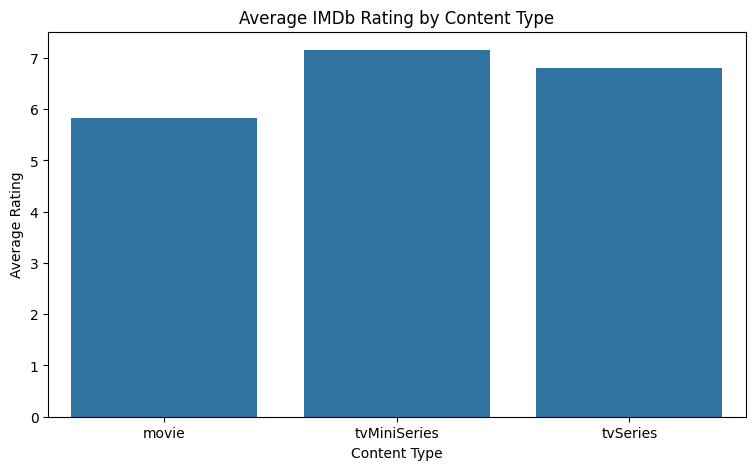

In [48]:
# Visualize the average IMDb rating by content type using a bar plot

plt.figure(figsize=(9, 5))

sns.barplot(
    data=type_rating,
    x="Content_Type",
    y="Average_Rating"
)

plt.title("Average IMDb Rating by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Rating")

plt.show()

Most Popular Titles

In [49]:
most_popular = (
    df.sort_values(
        "IMDb_Votes",
        ascending=False
    )
    .head(20)
)

most_popular[
    [
        "Title",
        "Content_Type",
        "Release_Year",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
]

,Title,Content_Type,Release_Year,IMDb_Rating,IMDb_Votes
12980,The Shawshank Redemption,movie,1994.0,9.3,3221305
40730,The Dark Knight,movie,2008.0,9.1,3207389
66548,Inception,movie,2010.0,8.8,2851551
46116,Breaking Bad,tvSeries,2008.0,9.5,2656080
46713,Game of Thrones,tvSeries,2011.0,9.2,2646209
18014,Fight Club,movie,1999.0,8.8,2644328
44302,Interstellar,movie,2014.0,8.7,2583532
12503,Forrest Gump,movie,1994.0,8.8,2521446
12892,Pulp Fiction,movie,1994.0,8.8,2456470
17774,The Matrix,movie,1999.0,8.7,2267463


## Initial EDA Insights

### Content Production
- 

### Rating Trends
- 

### Genre Performance
- 

### Popularity
- 

### Movie vs TV
- 

### Overall Observation
- 

# EDA Summary Table

In [50]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Titles",
        "Average IMDb Rating",
        "Median IMDb Rating",
        "Highest Rating",
        "Lowest Rating",
        "Total IMDb Votes",
        "Earliest Release Year",
        "Latest Release Year"
    ],
    "Value": [
        len(df),
        round(df["IMDb_Rating"].mean(), 2),
        round(df["IMDb_Rating"].median(), 2),
        df["IMDb_Rating"].max(),
        df["IMDb_Rating"].min(),
        df["IMDb_Votes"].sum(),
        df["Release_Year"].min(),
        df["Release_Year"].max()
    ]
})

eda_summary

,Metric,Value
0,Total Titles,1.563800e+05
1,Average IMDb Rating,6.100000e+00
2,Median IMDb Rating,6.300000e+00
3,Highest Rating,9.900000e+00
4,Lowest Rating,1.000000e+00
5,Total IMDb Votes,1.379274e+09
6,Earliest Release Year,1.980000e+03
7,Latest Release Year,2.026000e+03


In [51]:
genre_analysis.to_csv(
    "../data/processed/genre_analysis.csv",
    index=False
)

In [52]:
decade_analysis.to_csv(
    "../data/processed/decade_analysis.csv",
    index=False
)